#**Dataset Cifar-10**

O conjunto de dados CIFAR-10 consiste em 60000 imagens coloridas de 32x32 pixels de resolução, divididas em 10 classes, com 6000 imagens por classe. Cada imagem possui um rótulo que corresponde a classe à qual pertence. Há 50000 imagens de treinamento e 10000 imagens de teste.

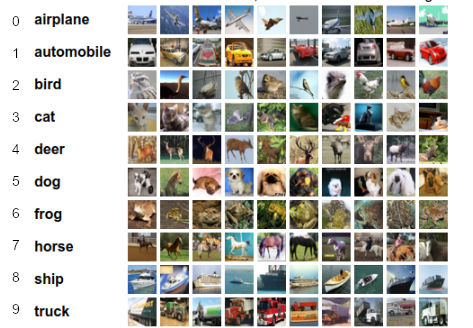

In [1]:
# Import the Keras library components we need:
# - datasets: provides built-in datasets (like MNIST, CIFAR-10, etc.)
# - models: lets us create and load neural network models
# - layers: building blocks of the network (Conv2D, Dense, etc.)
# - utils: helper functions (e.g. one-hot encoding labels)
# - backend: low-level operations (e.g. checking if using TensorFlow or Theano)
from keras import datasets, models, layers, utils, backend

# OpenCV: a powerful library for image processing (resizing, converting colors, etc.)
import cv2

# NumPy: used for numerical operations and working with arrays/matrices
import numpy as np

# Matplotlib: used to display images and plot graphs (like training accuracy/loss)
from matplotlib import pyplot as plt

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


c:\AI\postgrad-ai\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)


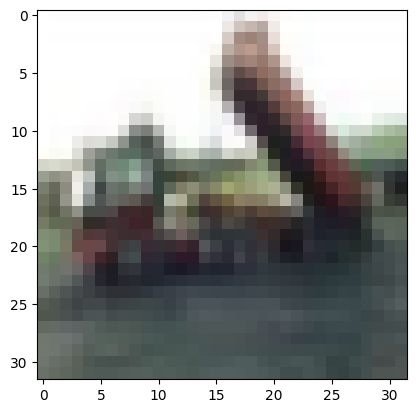

In [2]:
# Tell Keras that color channels come LAST in the image shape.
# So images are shaped as (height, width, channels) → e.g. (32, 32, 3)
# The 3 channels represent Red, Green, and Blue (RGB).
backend.set_image_data_format('channels_last')

# Load the CIFAR-10 dataset, already split into training and testing sets.
# - X_train / X_test: the images (input data)
# - Y_train / Y_test: the labels (what each image actually is, e.g. "cat", "dog")
# CIFAR-10 has 50,000 training images and 10,000 test images, each 32x32 pixels in RGB.
(X_train, Y_train), (X_test, Y_test) = datasets.cifar10.load_data()

# Grab the 3rd image from the training set (index 2) and display it.
# This is just a quick sanity check to see what the data looks like.
image = X_train[2]
plt.imshow(image)

# Print the shape of the training and test sets to understand the data dimensions.
# X_train shape will be: (50000, 32, 32, 3) → 50,000 images, 32x32 pixels, 3 color channels
# X_test shape will be:  (10000, 32, 32, 3) → 10,000 images
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Normalize the pixel values from a 0–255 integer range to 0.0–1.0 float range.
# This makes training faster and more stable — neural networks work better with small numbers.
# We cast to float32 first because division requires floating point math.
X_train = X_train.astype('float32') / 255
X_test  = X_test.astype('float32')  / 255

# Convert the labels from integers to one-hot encoded vectors.
# Example: the label "3" becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# This format is required for multi-class classification with a softmax output layer.
Y_train = utils.to_categorical(Y_train)
Y_test  = utils.to_categorical(Y_test)

# Define the number of classes in CIFAR-10.
# The 10 classes are: airplane, automobile, bird, cat, deer,
#                     dog, frog, horse, ship, truck.
num_classes = 10

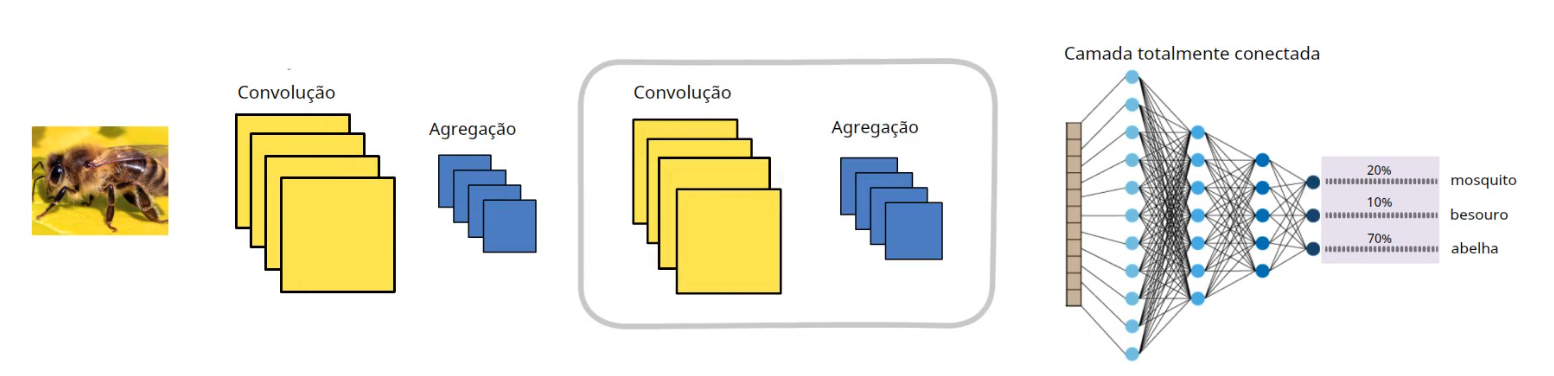

In [3]:
# Create a Sequential model — this means layers are stacked one after another,
# where the output of one layer becomes the input of the next.
model = models.Sequential()

# Define the input shape for each image: 32x32 pixels with 3 color channels (RGB).
# Your comment is correct! Each pixel has 3 values [R, G, B], each from 0–255.
# So the full image is a 3D array of shape (32, 32, 3):
#   - 32 rows of pixels
#   - 32 columns of pixels
#   - 3 values per pixel → [Red intensity, Green intensity, Blue intensity]
# Example: a red pixel = [255, 0, 0], a white pixel = [255, 255, 255], black = [0, 0, 0]
model.add(layers.Input(shape=(32, 32, 3)))

# --- CONVOLUTIONAL LAYER ---
# Applies 32 filters (feature detectors) of size 3x3 across the image.
# Each filter slides over the image with a step of 1 pixel (strides=(1,1))
# and learns to detect a pattern — like edges, curves, or color blobs.
# 'relu' (Rectified Linear Unit) is the activation function:
#   - It turns any negative value into 0, keeping only positive signals.
#   - This introduces non-linearity, helping the model learn complex patterns.
# Output shape: (30, 30, 32) → 32 filtered versions of a slightly smaller image.
model.add(layers.Conv2D(32, (3, 3), strides=(1, 1), activation='relu'))

# --- MAX POOLING LAYER ---
# Reduces the spatial size of the image by taking the MAX value in each 2x2 block.
# This makes the model more efficient and helps it focus on the most prominent features.
# It also adds some tolerance to small shifts or distortions in the image.
# Output shape: (15, 15, 32) → each dimension is halved.
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# --- DROPOUT LAYER (25%) ---
# During training, randomly turns off 25% of neurons in the previous layer.
# This prevents overfitting — where the model memorizes training data
# but fails to generalize to new, unseen images.
# Dropout is only active during training, not during prediction.
model.add(layers.Dropout(0.25))

# --- FLATTEN LAYER ---
# Converts the 3D output (15, 15, 32) into a 1D vector of 7200 values.
# This is necessary to feed the data into fully connected (Dense) layers,
# which expect a flat 1D input, not a 3D image.
model.add(layers.Flatten())

# --- FULLY CONNECTED (DENSE) LAYER ---
# Every neuron here is connected to all 7200 inputs from the Flatten layer.
# 512 neurons learn high-level combinations of the features extracted earlier.
# 'relu' again keeps only positive activations to learn complex relationships.
model.add(layers.Dense(512, activation='relu'))

# --- DROPOUT LAYER (50%) ---
# A heavier dropout (50%) is applied after the large Dense layer.
# Since Dense layers have many connections, they're more prone to overfitting,
# so a stronger regularization is used here.
model.add(layers.Dropout(0.5))

# --- OUTPUT LAYER ---
# 'num_classes' = 10 neurons, one for each CIFAR-10 category.
# 'softmax' converts raw scores into probabilities that sum to 1.0.
# Example output: [0.02, 0.01, 0.70, 0.05, ...] → 70% confident it's class 2 (bird).
# The class with the highest probability is the model's final prediction.
# Named 'predict' for easy reference later (e.g. when extracting this layer).
model.add(layers.Dense(num_classes, activation='softmax', name='predict'))

In [4]:
# --- COMPILE THE MODEL ---
# Before training, we must configure how the model learns. Three key settings:

# loss='categorical_crossentropy':
#   - This is the loss function — it measures how WRONG the model's predictions are.
#   - Used for multi-class classification problems (like our 10 CIFAR classes).
#   - It compares the predicted probability distribution (softmax output)
#     against the true one-hot encoded label.
#   - Example: true label = [0,0,1,0,...], predicted = [0.1, 0.1, 0.7, 0.1,...]
#     → the loss will be low because the model is mostly right.
#   - The goal of training is to MINIMIZE this loss value.

# optimizer='adam':
#   - Adam (Adaptive Moment Estimation) is the algorithm that updates the model's
#     weights after each batch to reduce the loss.
#   - It's one of the most popular optimizers because it automatically adjusts
#     the learning rate for each weight, making training faster and more stable.
#   - Think of it as the "engine" that drives the learning process.

# metrics=['accuracy']:
#   - This tells Keras to also track accuracy during training (in addition to loss).
#   - Accuracy = how many images were correctly classified / total images.
#   - This is just for monitoring — it does NOT affect how the model learns.
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- TRAIN THE MODEL ---
# This is where the actual learning happens. Key parameters:

# X_train, Y_train:
#   - The training images and their correct labels.
#   - The model will learn by repeatedly looking at these.

# validation_data=(X_test, Y_test):
#   - After each epoch, the model is evaluated on the TEST set (data it has never trained on).
#   - This tells us if the model is generalizing well or just memorizing training data.
#   - If training accuracy is high but validation accuracy is low → overfitting!

# epochs=5:
#   - One epoch = the model has seen ALL 50,000 training images once.
#   - With 5 epochs, the model passes through the full training set 5 times.
#   - More epochs can improve accuracy, but too many can cause overfitting.

# batch_size=64:
#   - Instead of updating weights after every single image (too slow) or all at once
#     (too memory-heavy), we process 64 images at a time.
#   - After each batch of 64, the optimizer updates the model's weights.
#   - 50,000 images / 64 per batch = ~781 weight updates per epoch.
model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=5, batch_size=64)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.4401 - loss: 1.5598 - val_accuracy: 0.5480 - val_loss: 1.2978
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5462 - loss: 1.2813 - val_accuracy: 0.5854 - val_loss: 1.1691
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5808 - loss: 1.1808 - val_accuracy: 0.6172 - val_loss: 1.0920
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.6070 - loss: 1.1068 - val_accuracy: 0.6210 - val_loss: 1.0707
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.6311 - loss: 1.0429 - val_accuracy: 0.6339 - val_loss: 1.0535


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Classe predita: automobile (100.00% confident)
Probabilidades preditas
0.0000
1.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000


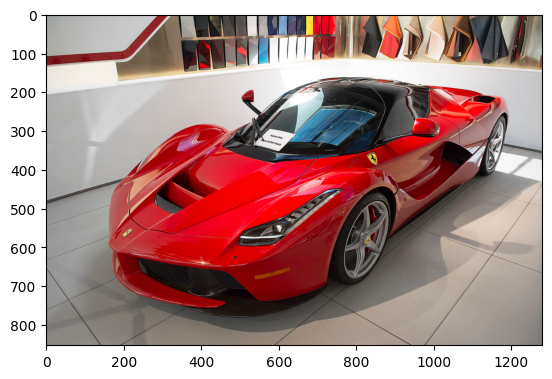

In [5]:
# --- LOAD A CUSTOM IMAGE FOR PREDICTION ---
# Read an image file from disk using OpenCV.
# OpenCV loads images in BGR format (Blue, Green, Red) by default,
# which is the opposite of the standard RGB format.
pred_img = cv2.imread('teste4.png')

# Convert the image from BGR (OpenCV default) to RGB (what our model expects).
# If we skip this step, colors would be swapped and predictions could be wrong,
# since the model was trained on RGB images (from CIFAR-10).
pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

# Display the image to visually confirm it loaded and converted correctly.
plt.imshow(pred_img)

# --- RESIZE THE IMAGE IF NEEDED ---
# Our model only accepts 32x32 images (the CIFAR-10 size it was trained on).
# If the loaded image has a different size, we resize it to 32x32.
# Note: pred_img.shape returns (height, width, channels), so comparing to
# (32, 32) only checks height and width — ignoring the 3 color channels.
if pred_img.shape != (32, 32):
    pred_img = cv2.resize(pred_img, (32, 32))

# --- RESHAPE FOR MODEL INPUT ---
# The model expects input in the shape (batch_size, height, width, channels).
# Our single image is currently (32, 32, 3), so we add a batch dimension:
# (32, 32, 3) → (1, 32, 32, 3) meaning "a batch of 1 image".
# Without this, the model would throw a shape error.
pred_img = pred_img.reshape(1, 32, 32, 3)

# --- RUN THE PREDICTION ---
# Feed the image through the model and get the output probabilities.
# pred_proba will be a 2D array of shape (1, 10):
#   - 1 row (our single image)
#   - 10 columns (one probability per CIFAR-10 class)
# All 10 values sum to 1.0 thanks to the softmax activation in the output layer.
pred_proba = model.predict(pred_img)

# --- FIND THE PREDICTED CLASS ---
# np.argmax finds the INDEX of the highest probability in the output array.
# That index corresponds to the predicted class (0–9).
# pred_proba[0] gets the first (and only) result from the batch.
classe_predita = np.argmax(pred_proba[0])

# Get the actual probability value of the predicted class.
# This tells us HOW CONFIDENT the model is in its prediction.
# Example: 0.8742 means the model is ~87% confident.
valor_maximo = pred_proba[0][classe_predita]

# Print the predicted class index (0–9).
# To know what class it is, you'd map it to the CIFAR-10 labels:
# 0=airplane, 1=automobile, 2=bird, 3=cat, 4=deer,
# 5=dog, 6=frog, 7=horse, 8=ship, 9=truck
# Optional improvement — map class index to human-readable label
labels = {0:'airplane', 1:'automobile', 2:'bird', 3:'cat', 4:'deer',
          5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}
print(f'Classe predita: {labels[classe_predita]} ({valor_maximo:.2%} confident)')

# Print all 10 predicted probabilities, formatted to 4 decimal places.
# This helps you see not just the winner, but how confident the model
# was across all classes. A good prediction has one dominant probability.
print('Probabilidades preditas')
for proba in pred_proba[0]:
    print(f'{proba:.4f}')